# Homework 3: VP-SDE Diffusion

In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output

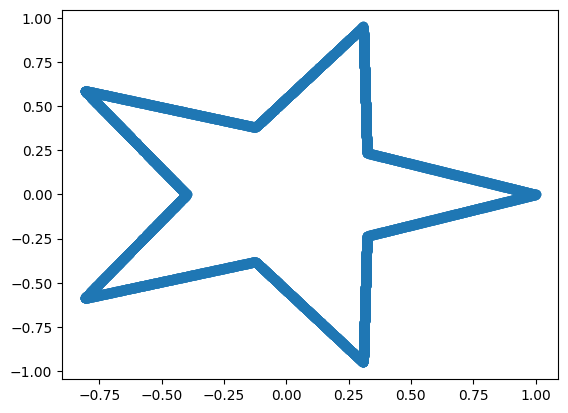

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class Config:
    beta_min = 0.1
    beta_max = 20.0

    lr = 1e-3
    epochs = 3000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

    schedule = 'linear'
    cosine_s = 0.008
    beta_clip = 20.0
    t_eps = 1e-3

## VP-SDE

$$dx = -\frac{1}{2}\beta(t)x\,dt + \sqrt{\beta(t)}\,dw$$

Переходное распределение: $x_t = \alpha(t) x_0 + \sigma(t) \varepsilon$, где $\alpha(t)^2 + \sigma(t)^2 \approx 1$.

In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [5]:
def alpha_bar_t(t, config):
    if config.schedule == 'linear':
        int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        return torch.exp(-int_beta)

    elif config.schedule == 'cosine':
        s = config.cosine_s
        u = (t + s) / (1.0 + s)
        c0 = torch.cos(torch.tensor(0.5 * np.pi * s / (1.0 + s), device=t.device)) ** 2
        abar = torch.cos(0.5 * np.pi * u) ** 2 / c0
        return torch.clamp(abar, min=1e-5, max=1.0)


def beta_t(t, config):
    if config.schedule == 'linear':
        beta = config.beta_min + t * (config.beta_max - config.beta_min)
        return torch.clamp(beta, min=1e-5, max=config.beta_clip)

    elif config.schedule == 'cosine':
        s = config.cosine_s
        u = (t + s) / (1.0 + s)
        beta = (np.pi / (1.0 + s)) * torch.tan(0.5 * np.pi * u)
        return torch.clamp(beta, min=1e-5, max=config.beta_clip)


def alpha_t(t, config):
    return torch.sqrt(alpha_bar_t(t, config))


def std_t(t, config):
    abar = alpha_bar_t(t, config)
    return torch.sqrt(torch.clamp(1.0 - abar, min=1e-5, max=1.0))


def drift_t(x, t, config):
    return -0.5 * beta_t(t, config) * x


def diffusion_t(t, config):
    return torch.sqrt(beta_t(t, config))

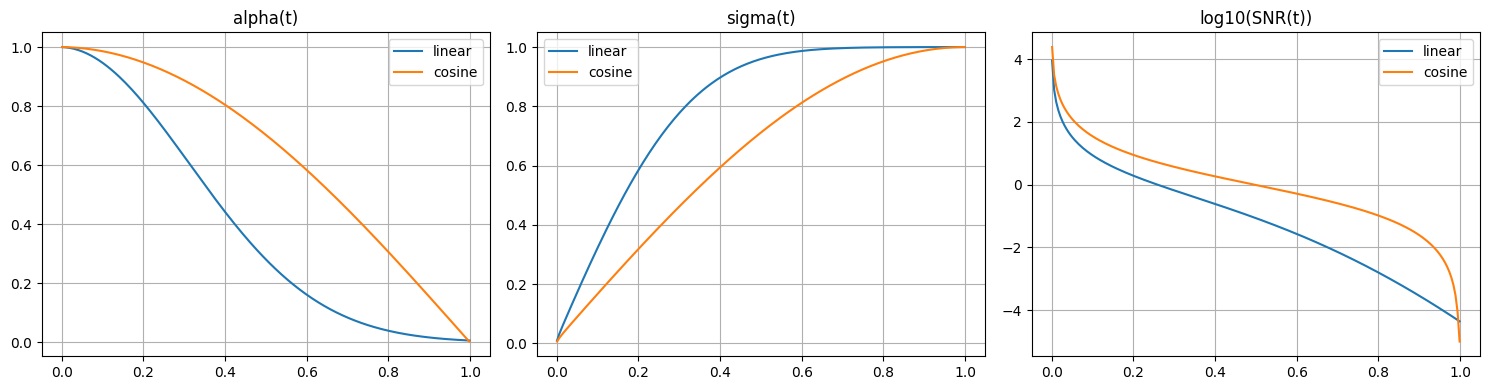

In [6]:
# визуализация расписаний
t_vis = torch.linspace(0.001, 0.999, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name in ['linear', 'cosine']:
    cfg = Config()
    cfg.schedule = name
    a = alpha_t(t_vis, cfg)
    s = std_t(t_vis, cfg)
    axes[0].plot(t_vis.numpy(), a.numpy(), label=f'{name}')
    axes[1].plot(t_vis.numpy(), s.numpy(), label=f'{name}')
    snr = (a / (s + 1e-8)) ** 2
    axes[2].plot(t_vis.numpy(), torch.log10(snr).numpy(), label=f'{name}')

axes[0].set_title('alpha(t)')
axes[1].set_title('sigma(t)')
axes[2].set_title('log10(SNR(t))')
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

## Trainer и Sampler

In [7]:
class VPSDETrainer():
    def __init__(self, config, weighting='none'):
        self.config = config
        self.weighting = weighting
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=config.batch_size,
            shuffle=True
        )

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def get_loss_weights(self, t):
        if self.weighting == 'none':
            return torch.ones_like(t)
        elif self.weighting == 't':
            return t
        elif self.weighting == '1-t':
            return 1.0 - t
        elif self.weighting == 'std2':
            s = std_t(t, self.config)
            return s ** 2
        else:
            raise ValueError(f'Unknown weighting: {self.weighting}')

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = self.config.t_eps + (1.0 - 2.0 * self.config.t_eps) * torch.rand(batch.shape[0], 1, device=self.device)
            z = torch.randn_like(batch)

            alpha = alpha_t(t, self.config)
            std = std_t(t, self.config)

            x_t = alpha * batch + std * z
            pred_z = self.model(x_t, t)

            per_sample_loss = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            weights = self.get_loss_weights(t)
            loss = (weights * per_sample_loss).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self, plot_every=100, sample_every=500):
        history = []
        real_data = self.data.numpy()

        for n in range(self.config.epochs):
            loss = self.train_epoch()
            history.append(loss)

            if n % plot_every == 0 or n == self.config.epochs - 1:
                clear_output(wait=True)

                do_sample = (n % sample_every == 0 and n > 0) or n == self.config.epochs - 1
                ncols = 3 if do_sample else 2
                fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))

                axes[0].plot(history)
                axes[0].set_title('Loss')
                axes[0].set_xlabel('Epoch')
                axes[0].set_ylabel('Loss')
                axes[0].grid(True)

                axes[1].scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
                axes[1].set_title('Real star')
                axes[1].axis('equal')
                axes[1].grid(True)

                if do_sample:
                    samples = sample_vp_sde(self.model, self.config, n_samples=2000).numpy()
                    axes[2].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
                    axes[2].set_title(f'Generated (epoch {n})')
                    axes[2].axis('equal')
                    axes[2].grid(True)

                plt.suptitle(
                    f'Epoch {n}/{self.config.epochs} | '
                    f'Loss: {loss:.6f} | '
                    f'Schedule: {self.config.schedule} | '
                    f'Weighting: {self.weighting}',
                    fontsize=12
                )
                plt.tight_layout()
                plt.show()

                print(f'Epoch {n}/{self.config.epochs} | Loss: {loss:.6f} | Min loss: {min(history):.6f}')

        return history

In [8]:
@torch.no_grad()
def sample_vp_sde(model, config, n_samples=2000):
    device = next(model.parameters()).device
    model.eval()

    x = torch.randn(n_samples, 2, device=device)

    eps = config.t_eps
    time_steps = torch.linspace(1.0 - eps, eps, config.num_timesteps, device=device)
    dt = time_steps[0] - time_steps[1]

    for i, t_scalar in enumerate(time_steps):
        t = torch.full((n_samples, 1), t_scalar, device=device)

        g = diffusion_t(t, config)
        std = std_t(t, config)

        pred_z = model(x, t)
        score = -pred_z / std

        f = drift_t(x, t, config)
        rev_drift = f - (g ** 2) * score

        x_mean = x - rev_drift * dt

        if i < len(time_steps) - 1:
            noise = torch.randn_like(x)
            x = x_mean + g * torch.sqrt(dt) * noise
        else:
            x = x_mean

    return x.cpu()

## Часть 1: VP-SDE

Базовая VP-SDE с линейным расписанием.

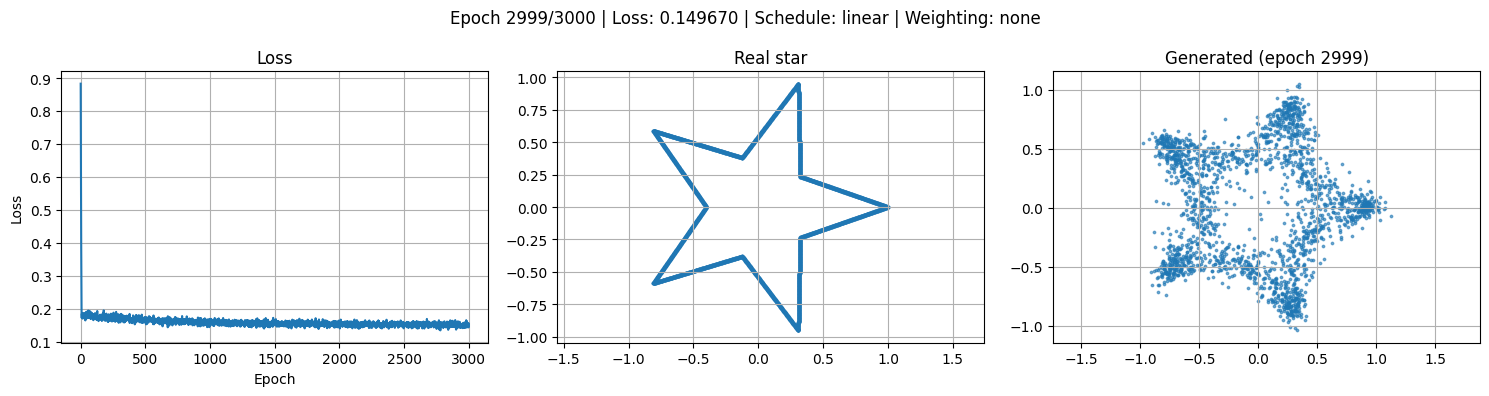

Epoch 2999/3000 | Loss: 0.149670 | Min loss: 0.133905


In [9]:
config = Config()
trainer = VPSDETrainer(config)
history_base = trainer.run(plot_every=100, sample_every=500)

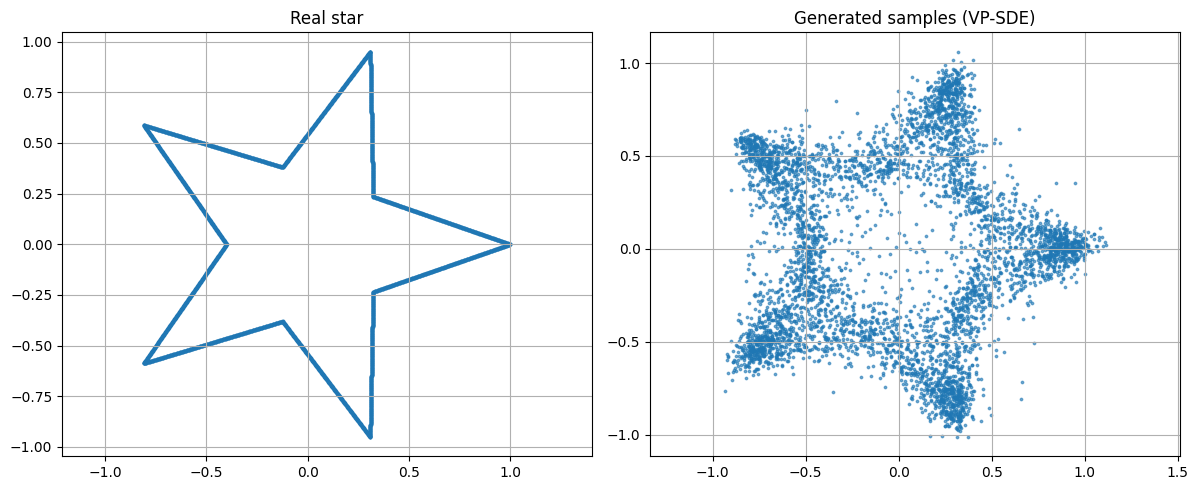

In [10]:
samples = sample_vp_sde(trainer.model, trainer.config, n_samples=5000).numpy()
real_data = trainer.data.numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
plt.title('Real star')
plt.axis('equal')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
plt.title('Generated samples (VP-SDE)')
plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()

## Часть 2: Перевзвешивание лосса (оценка 4)

Сравниваем 4 варианта перевзвешивания лосса при линейном расписании:
1. `none`: $w(t) = 1$
2. `t`: $w(t) = t$ — больше внимания шумным шагам
3. `1-t`: $w(t) = 1-t$ — больше внимания чистым шагам
4. `std2`: $w(t) = \sigma(t)^2$ — вес пропорционален дисперсии шума

In [11]:
def run_experiment(weighting, schedule='linear', epochs=1000, n_samples=5000):
    config = Config()
    config.schedule = schedule
    config.epochs = epochs

    trainer = VPSDETrainer(config, weighting=weighting)
    history = trainer.run(plot_every=200, sample_every=500)
    samples = sample_vp_sde(trainer.model, config, n_samples=n_samples).numpy()

    return {
        'weighting': weighting,
        'trainer': trainer,
        'history': history,
        'samples': samples
    }

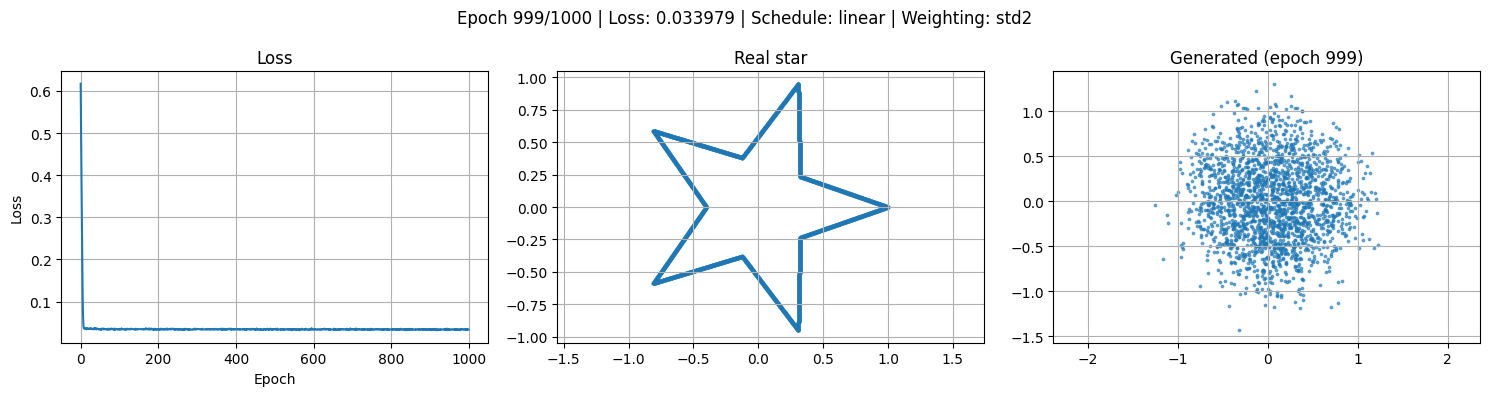

Epoch 999/1000 | Loss: 0.033979 | Min loss: 0.031680


In [12]:
weightings = ['none', 't', '1-t', 'std2']
results = {}

for w in weightings:
    print(f'\nRunning experiment: {w}')
    results[w] = run_experiment(weighting=w, epochs=1000, n_samples=5000)

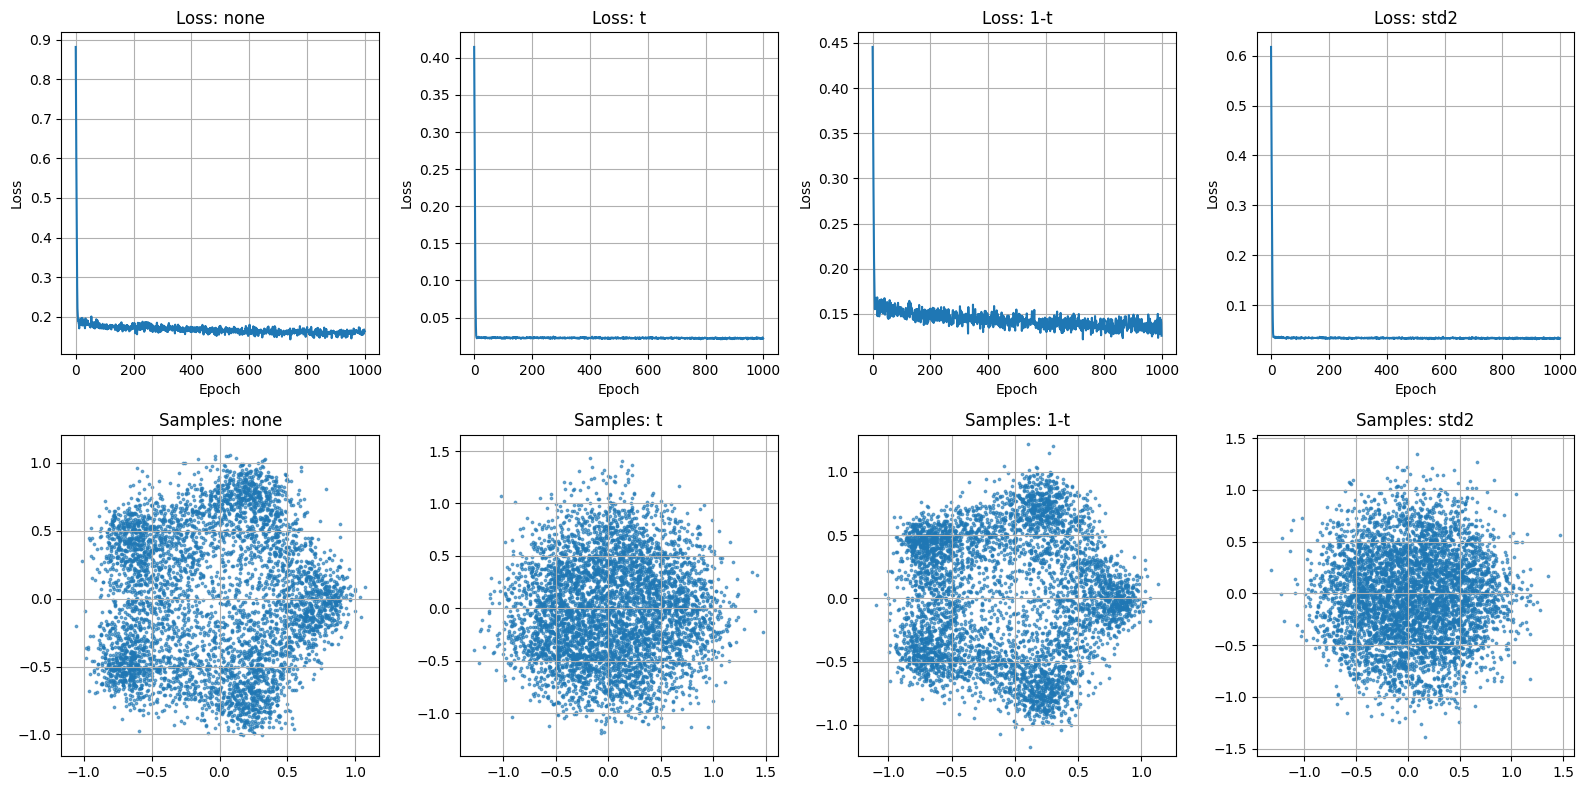

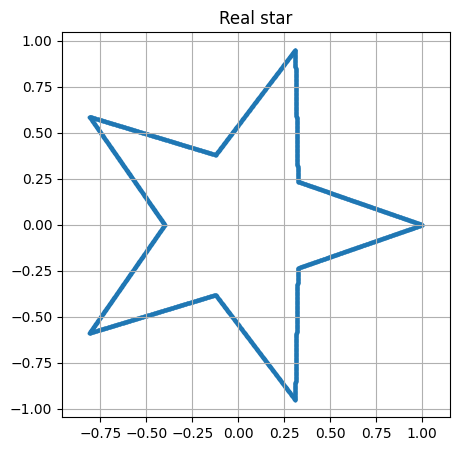

In [13]:
real_data = generate_star(n_samples=5000)

fig, axes = plt.subplots(2, len(weightings), figsize=(4 * len(weightings), 8))

for i, w in enumerate(weightings):
    history = results[w]['history']
    samples = results[w]['samples']

    axes[0, i].plot(history)
    axes[0, i].set_title(f'Loss: {w}')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].grid(True)

    axes[1, i].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
    axes[1, i].set_title(f'Samples: {w}')
    axes[1, i].axis('equal')
    axes[1, i].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
plt.title('Real star')
plt.axis('equal')
plt.grid(True)
plt.show()

### Вывод по перевзвешиванию лосса

Лучший вариант — `1-t`: он дал самую узнаваемую звезду с чёткими лучами.

`none` тоже учится, но форма менее чёткая.

`t` и `std2` дают более сглаженное, почти круговое распределение — хуже восстанавливают детали формы.

Значит, для этой задачи полезнее сильнее учитывать малые времена (когда $t \approx 0$), когда зашумлённый сэмпл ближе к данным и нужно точнее восстанавливать структуру.

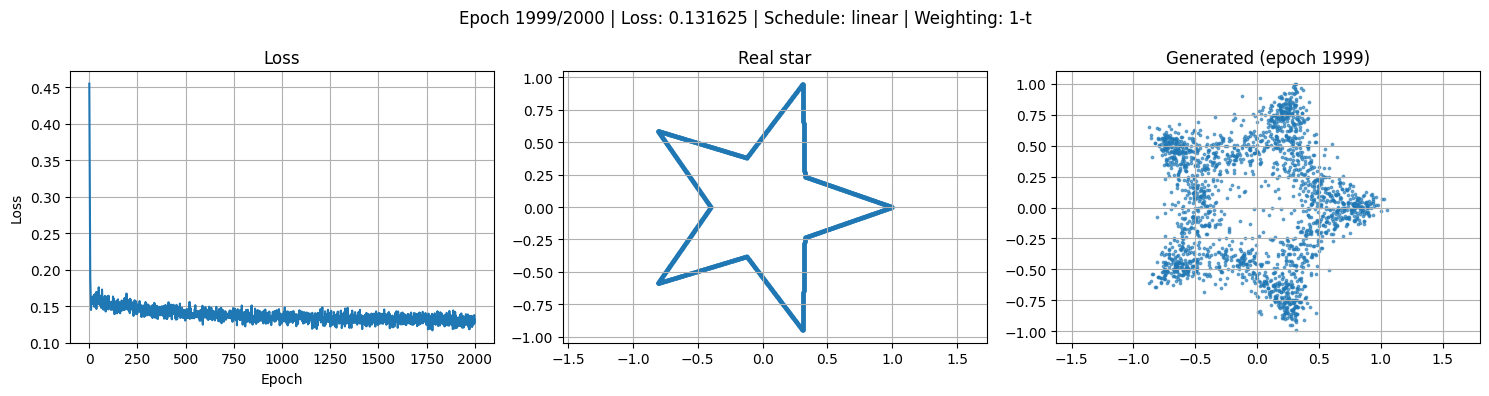

Epoch 1999/2000 | Loss: 0.131625 | Min loss: 0.116779


In [14]:
best_config = Config()
best_config.epochs = 2000

best_trainer = VPSDETrainer(best_config, weighting='1-t')
best_history = best_trainer.run(plot_every=100, sample_every=500)

## Часть 3: Сравнение расписаний

Сравниваем линейное и косинусовое расписание с лучшим перевзвешиванием (`1-t`).

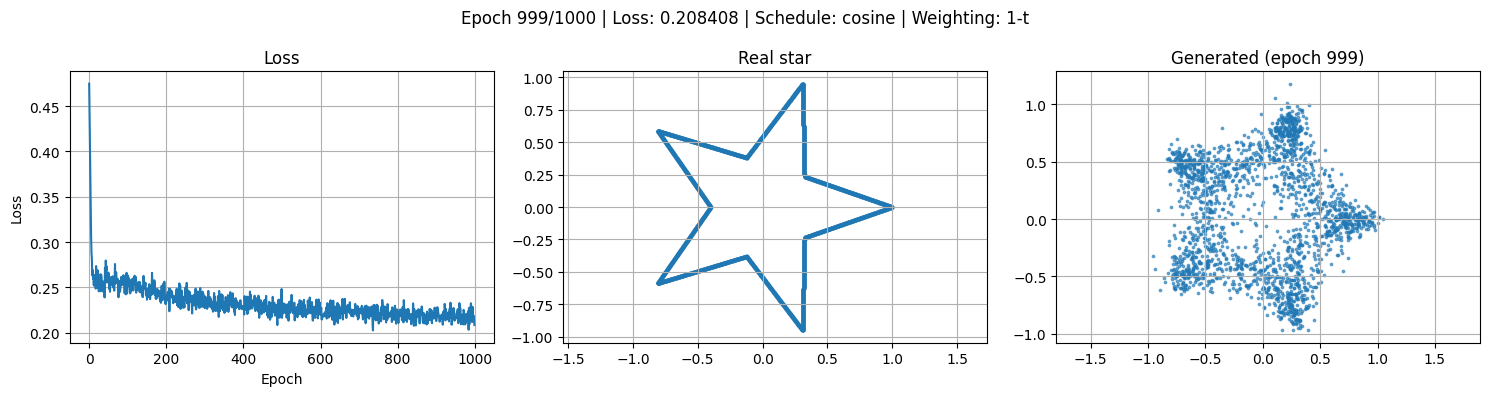

Epoch 999/1000 | Loss: 0.208408 | Min loss: 0.202502


In [15]:
schedules = ['linear', 'cosine']
schedule_results = {}

for sch in schedules:
    print(f'\nRunning schedule experiment: {sch}')

    config = Config()
    config.schedule = sch
    config.epochs = 1000

    trainer = VPSDETrainer(config, weighting='1-t')
    history = trainer.run(plot_every=200, sample_every=500)
    samples = sample_vp_sde(trainer.model, config, n_samples=5000).numpy()

    schedule_results[sch] = {
        'trainer': trainer,
        'history': history,
        'samples': samples
    }

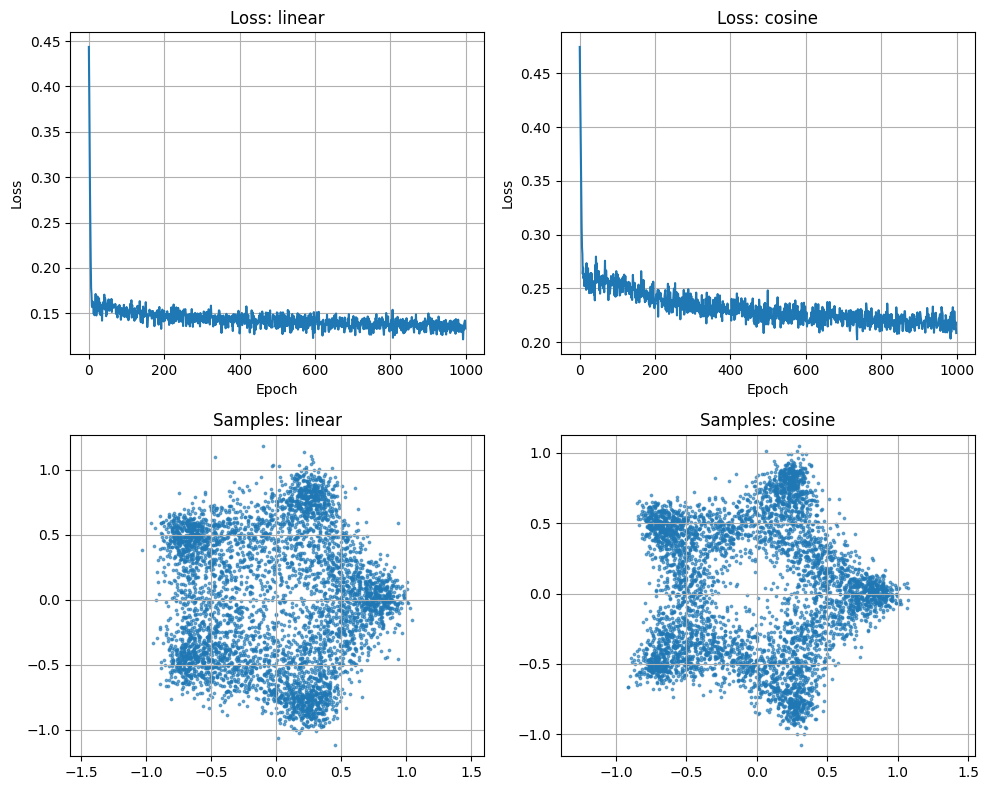

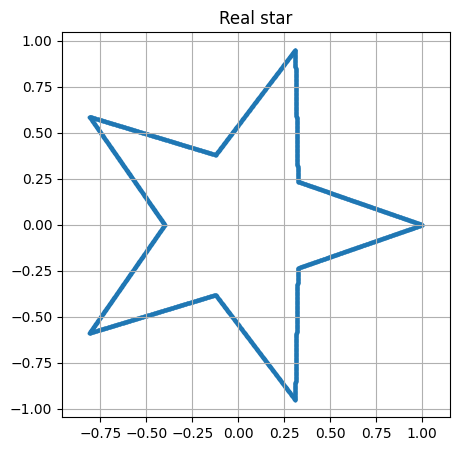

In [16]:
real_data = generate_star(n_samples=5000)

fig, axes = plt.subplots(2, len(schedules), figsize=(5 * len(schedules), 8))

for i, sch in enumerate(schedules):
    history = schedule_results[sch]['history']
    samples = schedule_results[sch]['samples']

    axes[0, i].plot(history)
    axes[0, i].set_title(f'Loss: {sch}')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].grid(True)

    axes[1, i].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
    axes[1, i].set_title(f'Samples: {sch}')
    axes[1, i].axis('equal')
    axes[1, i].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
plt.title('Real star')
plt.axis('equal')
plt.grid(True)
plt.show()

### Выводы

#### Сравнение перевзвешивания

Были сравнены четыре варианта перевзвешивания лосса по времени: `none`, `t`, `1-t` и `std2`. Основной вывод делался по визуальному качеству сгенерированной звезды.

- **`1-t`** — лучший результат: модель наиболее чётко восстановила лучи звезды и общую геометрию распределения.
- **`t`** и **`std2`** дали более сглаженное, почти круговое распределение, то есть хуже восстановили детали формы.
- Значит, для этой задачи полезнее сильнее учитывать малые времена, когда зашумлённый сэмпл ближе к данным и нужно точнее восстанавливать структуру.

#### Сравнение расписаний

- При **linear** звезда получается, но она более размытая и сильнее заполняется внутри.
- У **cosine** лучи видны чётче, форма более аккуратная и ближе к исходной звезде.
- Поэтому для этой задачи cosine schedule оказался удачнее — он более плавно распределяет уровень шума по времени, и модель получает больше обучающего сигнала на промежуточных уровнях.